# Support Vector Machine as Convex Optimization

#### In this demo, we show how to use cvxpy and pytorch to solve a classical machine learning problem -- support vector machine.

![SVM, see https://en.wikipedia.org/wiki/Support_vector_machine](https://upload.wikimedia.org/wikipedia/commons/thumb/7/72/SVM_margin.png/512px-SVM_margin.png)

## SVM

SVMs are a powerful supervised machine learning algorithm for classification and regression tasks. They are particularly well-suited for handling high-dimensional data and have proven effective in a wide range of applications, including text classification, image recognition, bioinformatics, and more.

## Mathematical Formulation

SVMs aim to find a hyperplane that best separates two classes in a dataset, while maximizing the margin between them. The hyperplane is defined by a weight vector $w$ and a bias term $b$.


###**Hard-margin SVM**

**Optimization**: given data $((x_i,y_i))_{i=1}^n$:

$$ \min_{w,b} \|w\|^2 \quad \text{subject to} \quad y_i(w \cdot x_i - b) \ge 1, \quad i = 1, \ldots, n.$$
- **$w$** is the weight vector
- **$b$** is the bias term
- **$x_i$** are the data points
- **$y_i$** are the class labels (+1 or -1)

This only works for linearly seperable data! That is, this problem has a solution if we can find a hyperplane that **perfectly separates data**.


###**Soft-Margin SVM**

Allow imperfect separation by adding a slack variable.

The soft margin SVM introduces slack variables to allow for some misclassifications, making it more robust to noise and outliers. The optimization problem for the soft margin SVM can be written in two forms:**

####Constrained Optimization Form:


   $\min_{w,b, \zeta}||w||^2 / 2 + C \cdot  \sum(\zeta_i)\quad $
subject to  $\quad y_i (w^T x_i + b) \geq  1 -  \zeta_i  \quad\textrm{and}\quad $   
             $\zeta_i >= 0\quad $  for all $i$


**where:**

- $C$ is a regularization parameter that controls the trade-off between margin maximization and misclassification error
- $\zeta_i$ are the slack variables that measure the degree of misclassification for each data point

#### Regularization Form with Hinge Loss:

Instead of having a relaxed constraint, we can construct a **regularized** and **uncontrained optimization** problem using the **hinge loss**. The gain is that now we can use gradient-based optimization methods.

This form is often used with gradient-based optimization methods, as the hinge loss is (sub)differentiable. We can leverage the **automatic differentiation tools**.


The optimization objective with regularization parameter $C > 0$:

$$ \min_{w,b}  \ \lVert w \rVert^2 + C\left[\frac 1 n \sum_{i=1}^n \underbrace{\max\left(0, 1 - y_i(w\cdot x_i - b)\right)}_{\text{hinge loss}} \right]$$


- $C$ represents a trade-off between increasing the margin size (smaller $C$) and ensuring that the $x_{i}$ lie on the correct side of the margin (larger $C$)

- After finding (approximate) minimizer $\hat{w}, \hat{b}$, the classifier is given by $x \mapsto \operatorname{sgn}(\hat{w} x-\hat{b})$.

In [1]:
!pip install numpy scikit-learn matplotlib cvxpy torch

In [2]:
import numpy as np
import sklearn
import matplotlib
import cvxpy as cp
import torch

from matplotlib import pyplot as plt
from matplotlib.colors import ListedColormap

np.random.seed(632)





In [3]:
## Define function that plots data points

def get_line(W, b, x):
    return (-W[0]*x+b)/W[1]

def plot_binary(X, Y, W=None, b=None):
    x1_min, x1_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    x2_min, x2_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    x1 = np.arange(x1_min, x1_max, .02)
    xx1, xx2 = np.meshgrid(x1, np.arange(x2_min, x2_max, .02))
    if W is not None and b is not None:
        decision = np.c_[xx1.ravel(), xx2.ravel()] @ W + b
        plt.contourf(xx1, xx2, decision.reshape(xx1.shape), cmap=plt.cm.RdBu, alpha=.8)
        plt.colorbar()
        for intercept in [-1,0,1]:
            plt.plot(x1, get_line(W, b + intercept, x1), c='black')
    cm_bright = ListedColormap(['#FF0000', '#0000FF'])
    plt.scatter(X[:,0],X[:,1], c=Y.ravel(), cmap=cm_bright)
    plt.xlim(x1_min, x1_max)
    plt.ylim(x2_min, x2_max)
    plt.show()




def plot_binary_with_model(X, Y, model, threshold=0):
    x1_min, x1_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    x2_min, x2_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    x1 = np.arange(x1_min, x1_max, .02)
    xx1, xx2 = np.meshgrid(x1, np.arange(x2_min, x2_max, .02))

    # Use the model to make predictions
    grid = np.c_[xx1.ravel(), xx2.ravel()]
    grid_tensor = torch.tensor(grid, dtype=torch.float32)
    decision_values = model(grid_tensor).detach().numpy()

    decision_binary = np.sign(decision_values - threshold)
    # Plot the decision boundary
    plt.contourf(xx1, xx2, decision_binary.reshape(xx1.shape), cmap=plt.cm.RdBu, alpha=.8)
    plt.colorbar()

    # Plot the data points
    cm_bright = ListedColormap(['#FF0000', '#0000FF'])
    plt.scatter(X[:,0], X[:,1], c=Y.ravel(), cmap=cm_bright)

    plt.xlim(x1_min, x1_max)
    plt.ylim(x2_min, x2_max)
    plt.show()

# Generate Data

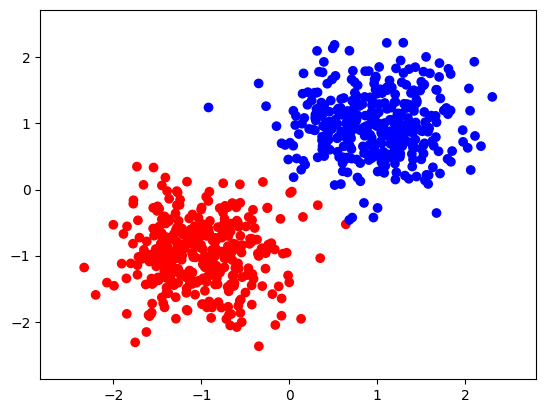

In [4]:
from sklearn.datasets import make_blobs

X, Y = make_blobs(n_samples=700, centers=[(-1, -1), (1, 1)], cluster_std=0.5)
Y[Y == 0] = -1 # to have +/- 1 labels


plot_binary(X, Y)

## Constrained version using cvxpy

To use cvxpy, define the variables, objective, and constraint, and that's it!

Optimal w: [17.99122184 19.84647851]
Optimal b: -2.1462980149482593


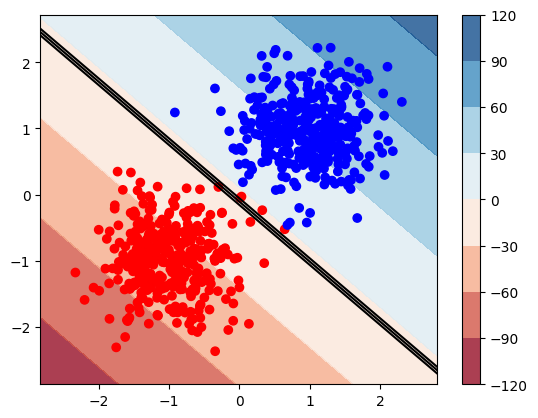

In [5]:
X = np.array(X)
Y = np.array(Y)

# Number of data points
n = X.shape[0]

# Create CVXPY variables for weights, bias, and slack variables
w = cp.Variable(X.shape[1])
b = cp.Variable()
zeta = cp.Variable(n)

# Set regularization parameter
C = 10.0  # You can adjust this value as needed

# Define the objective function
objective = cp.Minimize(cp.norm(w, 2) / 2 + C * cp.sum(zeta))

# Define the constraints
constraints = [
Y[i] * (cp.matmul(w, X[i]) + b) >= 1 - zeta[i] for i in range(n)
]
constraints += [zeta[i] >= 0 for i in range(n)]

# Create and solve the CVXPY problem
prob = cp.Problem(objective, constraints)
prob.solve()

# Extract the optimal values of w and b
w_opt = w.value
b_opt = b.value

print("Optimal w:", w_opt)
print("Optimal b:", b_opt)

# pytorch
plot_binary(X, Y, W=w_opt, b=b_opt)

## Regularized version using pytorch

We can use the automatic differentition of pytorch -- build a loss function based on variables
```
w = torch.randn(n_features, requires_grad=True)
b = torch.randn(1, requires_grad=True)
```
"requires_grad=True" means we want to compute the gradient with respect to $w$ ane $b$.

Then build a loss function and get gradient by
```
loss.backward()
```

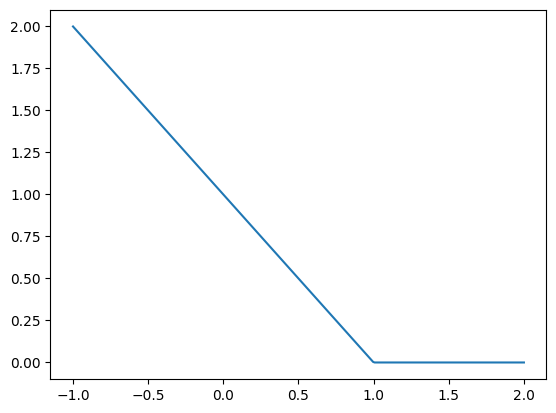

<function matplotlib.pyplot.show(close=None, block=None)>

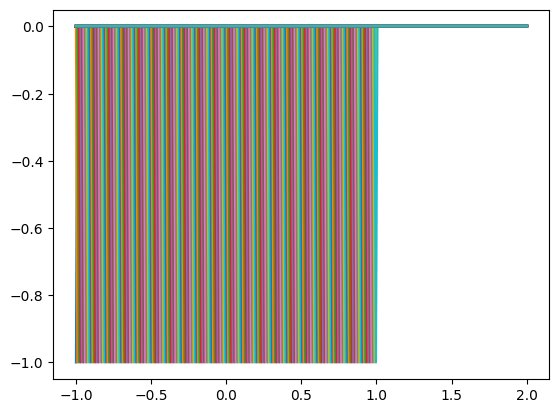

In [7]:
from matplotlib import pyplot as plt

def hinge(t):

    return torch.clamp(1 - t, min=0)


t = torch.linspace(-1,2,300)
# compute the subgradient of hinge loss
subgrad_hinge = torch.autograd.functional.jacobian(hinge, t)

plt.plot(t, hinge(t)) # PyTorch works well with matplotlib
plt.show()

plt.plot(t, subgrad_hinge)
plt.show

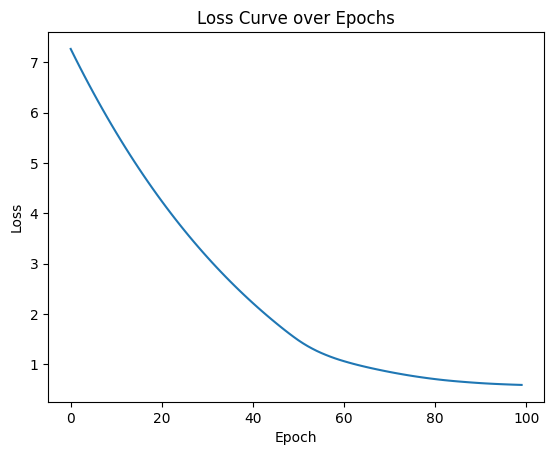

Optimal w: [0.441623   0.59791523]
Optimal b: [0.20917745]


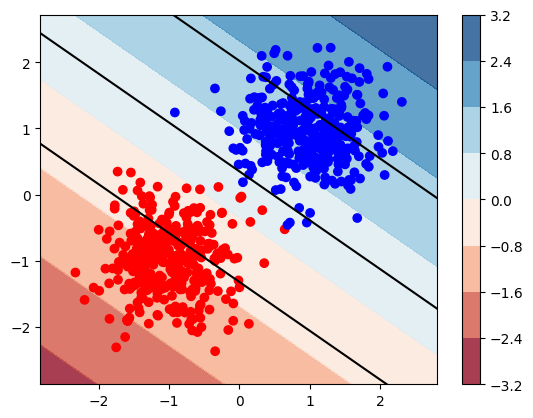

In [8]:
import torch
import matplotlib.pyplot as plt

# Assuming X and Y are already defined and are numpy arrays
X = torch.tensor(X, dtype=torch.float32)
Y = torch.tensor(Y, dtype=torch.float32)

# Number of features and data points
n_features = X.shape[1]
n_samples = X.shape[0]

# Initialize model parameters
w = torch.randn(n_features, requires_grad=True)
b = torch.randn(1, requires_grad=True)

# Hyperparameters
learning_rate = 0.01
C = 2
num_epochs = 100

# Define the hinge loss function
def hinge_loss(y_pred, y_true):
    return torch.clamp(1 - y_pred * y_true, min=0)

# Define soft-margin loss function
def softmargin_loss(w, b, X, Y):
    pred = X @ w + b
    hinge = hinge_loss(pred, Y).mean()
    return (w**2).sum() / 2.0 + C * hinge   # Regularization term

# Training loop
losses = []
for epoch in range(num_epochs):
    # Forward pass: Compute loss
    loss = softmargin_loss(w, b, X, Y)
    losses.append(loss.item())

    # Backward pass: Compute gradient
    loss.backward()

    # Update parameters
    with torch.no_grad():
        w -= learning_rate * w.grad
        b -= learning_rate * b.grad

        # Zero gradients
        w.grad.zero_()
        b.grad.zero_()

# Plotting the loss curve
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve over Epochs')
plt.show()


w_final = w.detach().numpy() # detach it from the computational graph
b_final = b.detach().numpy()

print("Optimal w:", w_final)
print("Optimal b:", b_final)

# pytorch
plot_binary(X, Y, W=w_final , b=b_final)



<ipython-input-9-6df05bc13e61>:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X, dtype=torch.float32)
<ipython-input-9-6df05bc13e61>:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Y = torch.tensor(Y, dtype=torch.float32)


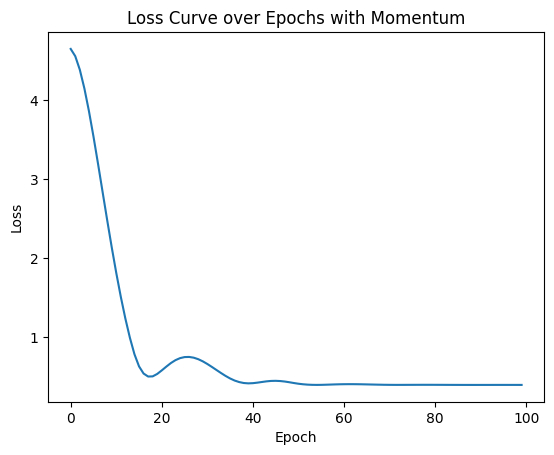

Optimal w: [0.48095843 0.45920482]
Optimal b: [0.01394239]


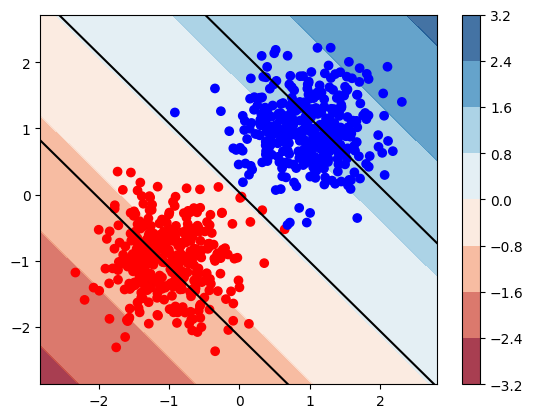

In [9]:
## Momemtum method

X = torch.tensor(X, dtype=torch.float32)
Y = torch.tensor(Y, dtype=torch.float32)


# Number of features and data points
n_features = X.shape[1]
n_samples = X.shape[0]

# Initialize model parameters
w = torch.randn(n_features, requires_grad=True)
b = torch.randn(1, requires_grad=True)

# Hyperparameters
learning_rate = 0.01
C = 1.0
num_epochs = 100
momentum = 0.9

# Initialize momentum terms
w_momentum = torch.zeros_like(w)
b_momentum = torch.zeros_like(b)


# Training loop
losses = []
for epoch in range(num_epochs):
    # Forward pass: Compute loss
    loss = softmargin_loss(w, b, X, Y)
    losses.append(loss.item())

    # Backward pass: Compute gradient
    loss.backward()

    # Update parameters with momentum
    with torch.no_grad():
        w_momentum = momentum * w_momentum + learning_rate * w.grad
        b_momentum = momentum * b_momentum + learning_rate * b.grad

        w -= w_momentum
        b -= b_momentum

        # Zero gradients
        w.grad.zero_()
        b.grad.zero_()

# Plotting the loss curve
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve over Epochs with Momentum')
plt.show()


w_final = w.detach().numpy() # detach it from the computational graph
b_final = b.detach().numpy()

print("Optimal w:", w_final)
print("Optimal b:", b_final)

# pytorch
plot_binary(X, Y, W=w_final , b=b_final)


## We can also use the built-in optimizer in pytorch

Link:https://pytorch.org/docs/stable/optim.html

PyTorch's built-in optimizers for mini-batch gradient descent, we can leverage the DataLoader class to handle mini-batches and use different optimizers like SGD (with and without momentum), Adagrad, and Adam.

In [10]:
from torch.utils.data import TensorDataset, DataLoader

# convert data into tensor
X_tensor = torch.tensor(X, dtype=torch.float32)
Y_tensor = torch.tensor(Y, dtype=torch.float32)

# Create dataset and data loader
dataset = TensorDataset(X_tensor, Y_tensor)
batch_size = 100
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

<ipython-input-10-9ea2d207da53>:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_tensor = torch.tensor(X, dtype=torch.float32)
<ipython-input-10-9ea2d207da53>:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Y_tensor = torch.tensor(Y, dtype=torch.float32)


Optimizer: SGD
w: tensor([-0.2545, -0.1287])
b: tensor([0.1384])

Optimizer: Momentum
w: tensor([ 0.0065, -0.0073])
b: tensor([0.0040])

Optimizer: Adagrad
w: tensor([ 0.1664, -0.0098])
b: tensor([0.0026])

Optimizer: Adam
w: tensor([-0.0003, -0.0225])
b: tensor([-0.0002])



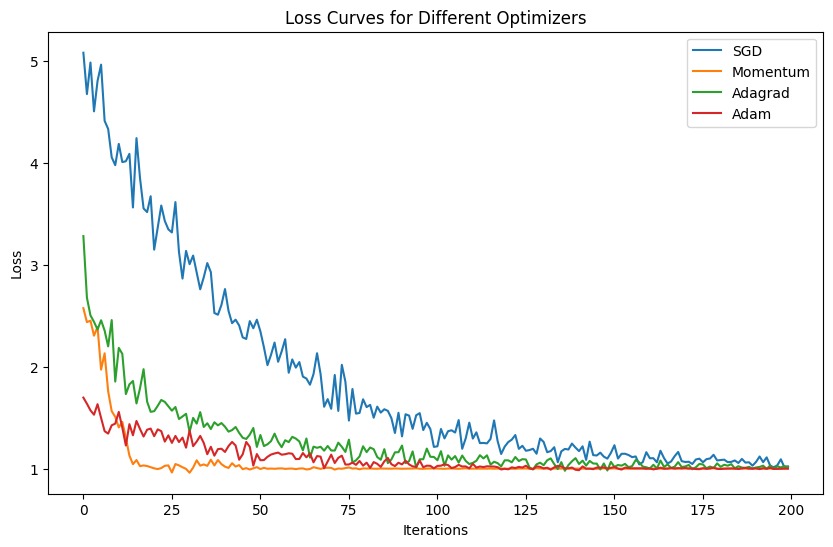

In [15]:
# Define the model
class SVMModel(torch.nn.Module):
    def __init__(self, n_features):
        super(SVMModel, self).__init__()
        self.w = torch.nn.Parameter(torch.randn(n_features))
        self.b = torch.nn.Parameter(torch.randn(1))

    def forward(self, X):
        return X @ self.w + self.b



# Hyperparameters
learning_rate = 0.01
C = 1.0
num_epochs = 20

# Optimizers
optimizers = {
    "SGD": lambda params: torch.optim.SGD(params, lr=learning_rate),
    "Momentum": lambda params: torch.optim.SGD(params, lr=learning_rate, momentum=0.9),
    "Adagrad": lambda params: torch.optim.Adagrad(params, lr=learning_rate*10),
    "Adam": lambda params: torch.optim.Adam(params, lr=learning_rate)
}


# convert data into tensor
X_tensor = torch.tensor(X, dtype=torch.float32)
Y_tensor = torch.tensor(Y, dtype=torch.float32)

# Create dataset and data loader
dataset = TensorDataset(X_tensor, Y_tensor)
batch_size = 50
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)



# Store losses for each optimizer
all_losses = {}

# Training and Evaluation
for name, opt_func in optimizers.items():
    # Initialize model
    model = SVMModel(X_tensor.shape[1])
    optimizer = opt_func(model.parameters())

    # Training loop
    losses = []
    for epoch in range(num_epochs):
        for X_batch, Y_batch in dataloader:
            # Forward pass
            loss = softmargin_loss(model, X_batch, Y_batch, C)
            losses.append(loss.item())

            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    # Store the losses
    all_losses[name] = losses

    # Print final parameters
    print(f"Optimizer: {name}")
    print(f"w: {model.w.data}")
    print(f"b: {model.b.data}\n")

# Plotting all loss curves together
plt.figure(figsize=(10, 6))
for name, losses in all_losses.items():
    plt.plot(losses, label=name)

plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Loss Curves for Different Optimizers')
plt.legend()
plt.show()


# Nonlinear data

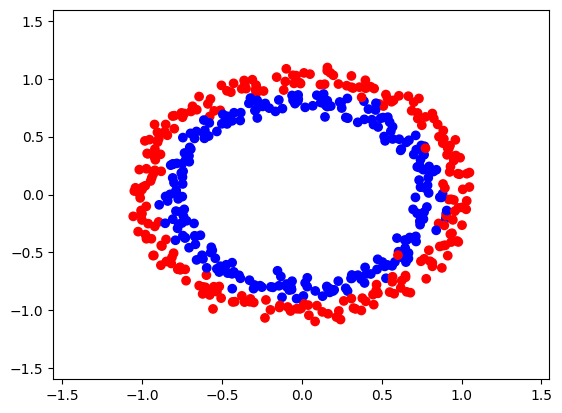

In [12]:
from sklearn.datasets import make_circles

X, Y = make_circles(n_samples=500, noise=0.05)
Y[Y == 0] = -1 #to have +/- 1 labels
plot_binary(X, Y)

Optimal w: [ 0.34352527 -0.97232388]
Optimal b: 0.08995546366472504


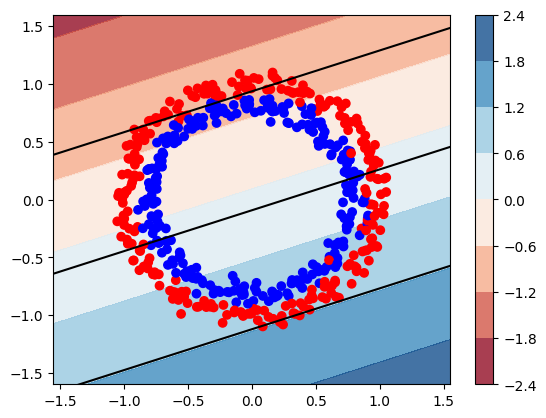

In [13]:
X = np.array(X)
Y = np.array(Y)

# Number of data points
n = X.shape[0]

# Create CVXPY variables for weights, bias, and slack variables
w = cp.Variable(X.shape[1])
b = cp.Variable()
zeta = cp.Variable(n)

# Set regularization parameter
C = 2.0  # You can adjust this value as needed

# Define the objective function
objective = cp.Minimize(cp.norm(w, 2) / 2 + C * cp.sum(zeta))

# Define the constraints
constraints = [
Y[i] * (cp.matmul(w, X[i]) + b) >= 1 - zeta[i] for i in range(n)
]
constraints += [zeta[i] >= 0 for i in range(n)]

# Create and solve the CVXPY problem
prob = cp.Problem(objective, constraints)
prob.solve()

# Extract the optimal values of w and b
w_opt = w.value
b_opt = b.value

print("Optimal w:", w_opt)
print("Optimal b:", b_opt)

# pytorch
plot_binary(X, Y, W=w_opt, b=b_opt)

## Let's try a nonlinear model -- two layer NN

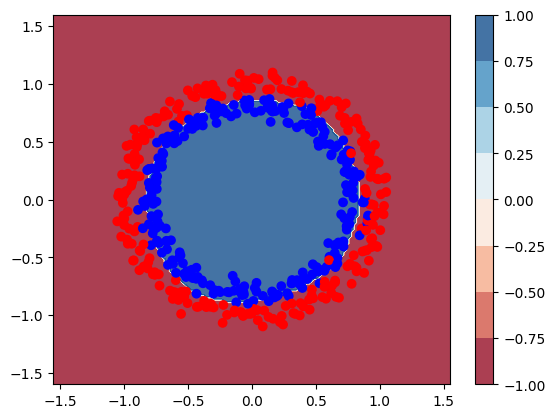

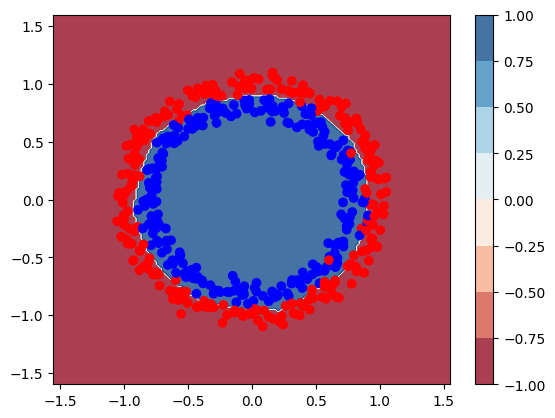

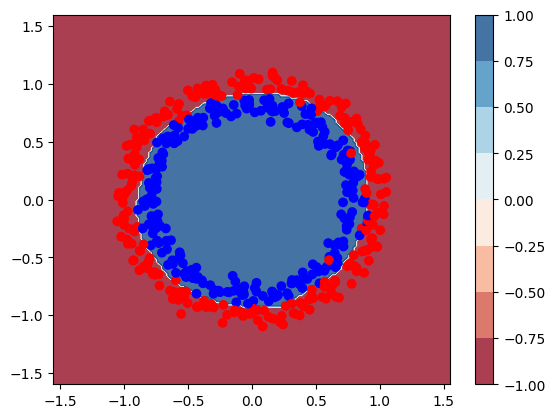

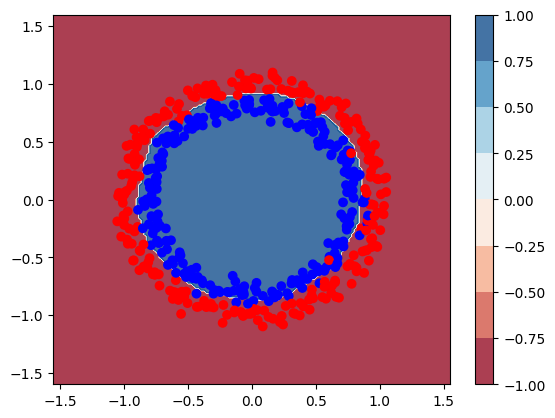

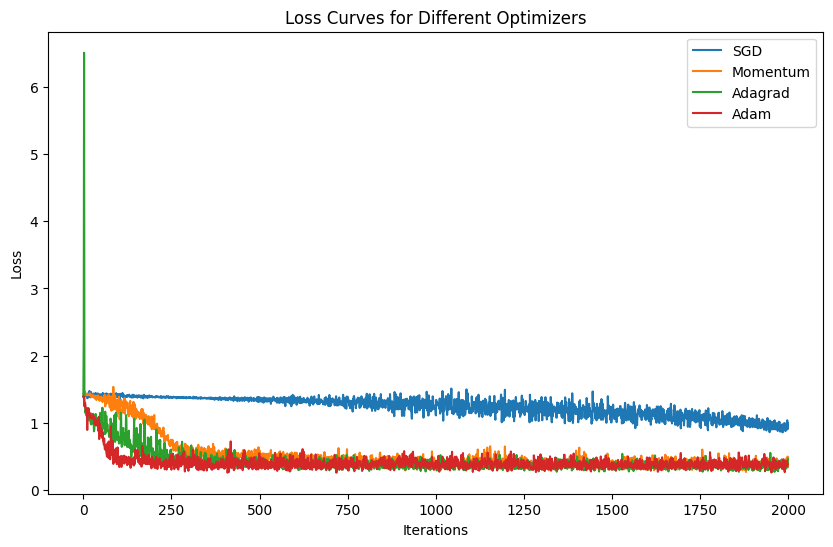

In [14]:
import torch.nn as nn
import torch.nn.functional as F

class TwoLayerReLUModel(nn.Module):
    def __init__(self, n_features, hidden_size):
        super(TwoLayerReLUModel, self).__init__()
        # First linear layer
        self.fc1 = nn.Linear(n_features, hidden_size)
        # Second linear layer
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, 1)

    def forward(self, X):
        # First layer with ReLU activation
        X = F.relu(self.fc1(X))
        X = F.relu(self.fc2(X))
        # Output layer
        return self.fc3(X)

# modify the loss function
def softmargin_loss(model, X, Y, C):
    # Forward pass to get the model's predictions
    pred = model(X).squeeze()  # Make sure the prediction is of the same shape as Y

    # Calculate hinge loss
    hinge = torch.clamp(1 - pred * Y, min=0).mean()

    # Regularization term: Sum of squares of all weights
    reg = sum(torch.sum(weight ** 2) for weight in model.parameters())

    # Total loss: Hinge loss + Regularization term
    return hinge + C * reg / 2.0



hidden_size = 100  # You can adjust this value


# convert data into tensor
X_tensor = torch.tensor(X, dtype=torch.float32)
Y_tensor = torch.tensor(Y, dtype=torch.float32)

# Create dataset and data loader
dataset = TensorDataset(X_tensor, Y_tensor)
batch_size = 50
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)


# Hyperparameters
learning_rate = 0.01
C = 0.01
num_epochs = 200

# Optimizers
optimizers = {
    "SGD": lambda params: torch.optim.SGD(params, lr=learning_rate),
    "Momentum": lambda params: torch.optim.SGD(params, lr=learning_rate, momentum=0.9),
    "Adagrad": lambda params: torch.optim.Adagrad(params, lr=learning_rate*10),
    "Adam": lambda params: torch.optim.Adam(params, lr=learning_rate)
}

# Store losses for each optimizer
all_losses = {}

# Training and Evaluation
for name, opt_func in optimizers.items():
    # Initialize model
    model = TwoLayerReLUModel(X_tensor.shape[1], hidden_size)
    optimizer = opt_func(model.parameters())

    # Training loop
    losses = []
    for epoch in range(num_epochs):
        for X_batch, Y_batch in dataloader:
            # Forward pass
            loss = softmargin_loss(model, X_batch, Y_batch, C)
            losses.append(loss.item())

            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    # Store the losses
    all_losses[name] = losses
    plot_binary_with_model(X, Y, model)



# Plotting all loss curves together
plt.figure(figsize=(10, 6))
for name, losses in all_losses.items():
    plt.plot(losses, label=name)

plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Loss Curves for Different Optimizers')
plt.legend()
plt.show()


